In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import FeatureGroup, LayerControl

from network_system import StationGraph, StationNode

stations = pd.read_pickle("bkk_data/stations.pkl")
edges = pd.read_pickle("bkk_data/edges.pkl")

stations = stations[~stations['stop_name'].str.contains(r'\sH(?:\s|$|\[)', regex=True)].copy()

print(f"Loaded {len(stations)} urban stations (excluding HÉV).")

Loaded 5504 urban stations (excluding HÉV).


In [ ]:
def get_district(name):
    match = re.search(r'\[([IVXLCDM]+)\.\]', str(name))
    return match.group(1) if match else "City Center"

def get_detailed_mode(name):
    name_str = str(name)
    if " M" in name_str: return "Metro"
    
    tram_keywords = ['villamos', 'tér', 'út', 'utca', 'körtér']
    if any(word in name_str.lower() for word in tram_keywords) and "autóbusz" not in name_str.lower():
        return "Tram"
    return "Bus"

stations['district'] = stations['stop_name'].apply(get_district)
stations['primary_mode'] = stations['stop_name'].apply(get_detailed_mode)

/tmp/ipykernel_29544/1902777622.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mode_acc.index, y=mode_acc.values, palette="magma", ax=axes[2])


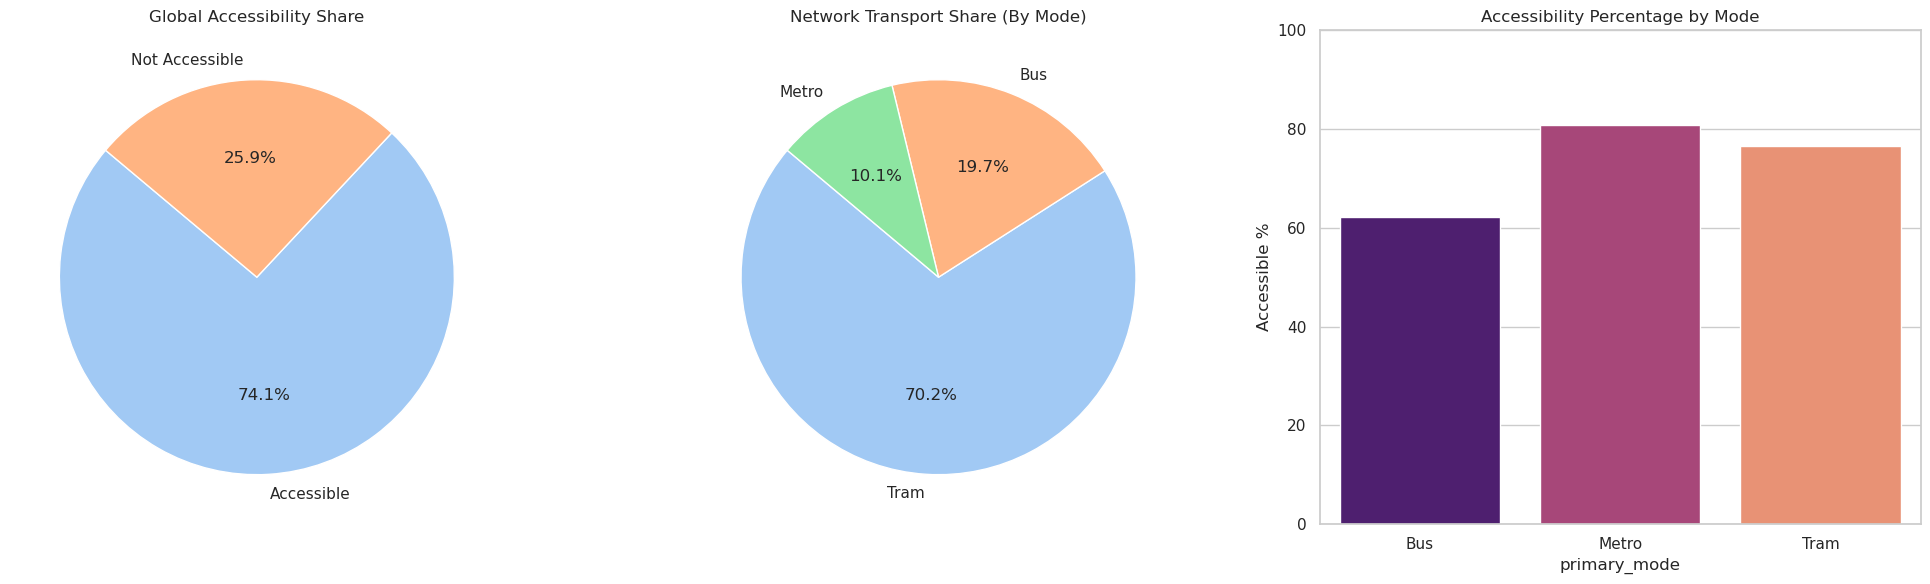

Global Accessibility Share: 74.15%


In [ ]:
total_share = stations['is_acc'].mean() * 100
mode_acc = stations.groupby('primary_mode')['is_acc'].mean() * 100
mode_counts = stations['primary_mode'].value_counts()

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Overall Accessibility (Pie Chart)
axes[0].pie([total_share, 100 - total_share], 
            labels=["Accessible", "Not Accessible"], 
            autopct='%1.1f%%', 
            colors=sns.color_palette("pastel")[0:2],
            startangle=140)
axes[0].set_title("Global Accessibility Share")

# Plot 2: Transport Share (Pie Chart)
axes[1].pie(mode_counts, 
            labels=mode_counts.index, 
            autopct='%1.1f%%', 
            colors=sns.color_palette("pastel"),
            startangle=140)
axes[1].set_title("Network Transport Share (By Mode)")

# Plot 3: Accessibility % by Mode (Bar Chart)
sns.barplot(x=mode_acc.index, y=mode_acc.values, palette="magma", ax=axes[2])
axes[2].set_title("Accessibility Percentage by Mode")
axes[2].set_ylabel("Accessible %")
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"Global Accessibility Share: {total_share:.2f}%")

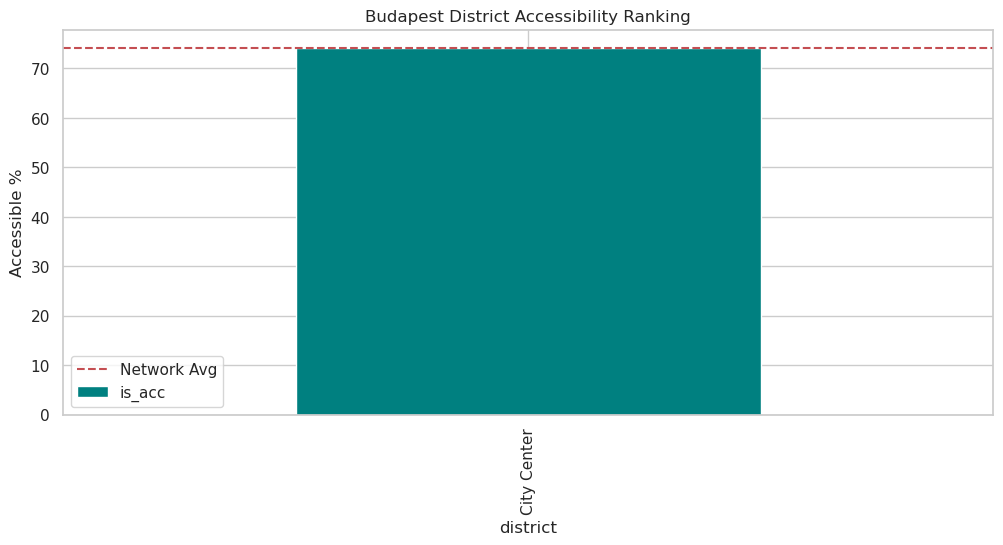

--- REGIONAL ACCESSIBILITY RANKINGS ---

Top 5 Most Accessible Districts:
District City Center: 74.15%

Bottom 5 Weakest Districts:
District City Center: 74.15%

Weakest Mode: Bus (62.25%)


In [10]:
dist_acc = stations.groupby('district')['is_acc'].mean() * 100

plt.figure(figsize=(12, 5))
dist_acc.sort_values().plot(kind='bar', color='teal')
plt.title("Budapest District Accessibility Ranking")
plt.ylabel("Accessible %")
plt.axhline(y=total_share, color='r', linestyle='--', label="Network Avg")
plt.legend()
plt.show()

top_5_districts = dist_acc.sort_values(ascending=False).head(5)
bottom_5_districts = dist_acc.sort_values(ascending=True).head(5)

print("--- REGIONAL ACCESSIBILITY RANKINGS ---")
print("\nTop 5 Most Accessible Districts:")
for dist, val in top_5_districts.items():
    print(f"District {dist}: {val:.2f}%")

print("\nBottom 5 Weakest Districts:")
for dist, val in bottom_5_districts.items():
    print(f"District {dist}: {val:.2f}%")

print(f"\nWeakest Mode: {mode_acc.idxmin()} ({mode_acc.min():.2f}%)")

/tmp/ipykernel_29544/3201916720.py:1: DtypeWarning: Columns (0: route_id) have mixed types. Specify dtype option on import or set low_memory=False.
  trips = pd.read_csv("bkk_data/trips.txt", usecols=['trip_id', 'route_id'])


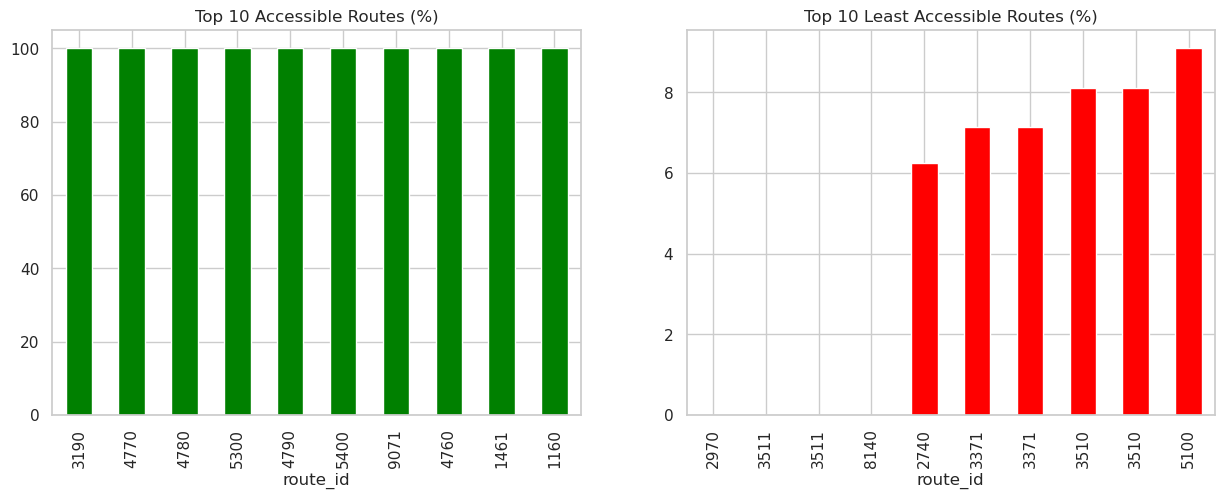

In [11]:
trips = pd.read_csv("bkk_data/trips.txt", usecols=['trip_id', 'route_id'])
st_lite = pd.read_csv("bkk_data/stop_times.txt", usecols=['trip_id', 'stop_id'])
stops_ref = pd.read_csv("bkk_data/stops.txt", usecols=['stop_id', 'parent_station'])
stops_ref['sid'] = stops_ref['parent_station'].fillna(stops_ref['stop_id'])

route_map = st_lite.merge(trips, on='trip_id').merge(stops_ref[['stop_id', 'sid']], on='stop_id')
route_map = route_map[['route_id', 'sid']].drop_duplicates()
route_acc = route_map.merge(stations[['station_id', 'is_acc']], left_on='sid', right_on='station_id')

route_metrics = route_acc.groupby('route_id')['is_acc'].mean() * 100
route_metrics = route_metrics[~route_metrics.index.astype(str).str.startswith('H')]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
route_metrics.sort_values(ascending=False).head(10).plot(kind='bar', ax=ax[0], color='green')
ax[0].set_title("Top 10 Accessible Routes (%)")
route_metrics.sort_values().head(10).plot(kind='bar', ax=ax[1], color='red')
ax[1].set_title("Top 10 Least Accessible Routes (%)")
plt.show()

In [24]:
net = StationGraph()

for s in stations.itertuples():
    net.add_station(StationNode(
        id=s.station_id, 
        name=s.stop_name, 
        lat=s.stop_lat, 
        lon=s.stop_lon, 
        is_accessible=s.is_acc  # Ensure this matches your dataclass field name
    ))

for e in edges.itertuples():
    if e.sid in net.nodes and e.next_sid in net.nodes:
        net.add_connection(e.sid, e.next_sid)

print(f"Graph built safely with {len(net.nodes)} nodes and validated edges.")

hub_id = stations[stations['stop_name'].str.contains("Deák Ferenc tér")].iloc[0]['station_id']
acc_reachable = net.get_reachable(hub_id, accessible_only=True)
full_reachable = net.get_reachable(hub_id, accessible_only=False)

print(f"--- Reachability Gap from Hub (Deák Ferenc tér) ---")
print(f"Total reachable stations: {len(full_reachable)}")
print(f"Accessible reachable stations: {len(acc_reachable)}")
print(f"Mobility Score: {(len(acc_reachable)/len(full_reachable))*100:.2f}%")

Graph built safely with 5504 nodes and validated edges.
--- Reachability Gap from Hub (Deák Ferenc tér) ---
Total reachable stations: 4345
Accessible reachable stations: 2141
Mobility Score: 49.28%


In [ ]:
m = folium.Map(location=[47.4979, 19.0402], zoom_start=12, tiles='cartodbpositron')

layers = {
    "Metro": FeatureGroup(name="Metro Network"),
    "Tram": FeatureGroup(name="Tram Network"),
    "Bus": FeatureGroup(name="Bus Network")
}

for node in net.nodes.values():
    mode = stations[stations['station_id'] == node.id]['primary_mode'].values[0]
    color = 'green' if node.is_accessible else 'red'
    
    marker = folium.CircleMarker(
        location=[node.lat, node.lon],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"<b>{node.name}</b><br>Mode: {mode}<br>Accessible: {node.is_accessible}"
    )
    
    if mode in layers: marker.add_to(layers[mode])
    else: marker.add_to(layers["Bus"])

for layer in layers.values(): layer.add_to(m)
LayerControl().add_to(m)

m.save("bkk_layered_accessibility_map.html")
print("Analysis complete. Layered map saved as bkk_layered_accessibility_map.html")

Analysis complete. Layered map saved as bkk_layered_accessibility_map.html


In [ ]:
hub_node = net.nodes[hub_id]
m = folium.Map(location=[hub_node.lat, hub_node.lon], zoom_start=13, tiles='cartodbpositron')

for station_id, node in net.nodes.items():
    if station_id == hub_id:
        color = 'blue'
        radius = 8
        label = "STARTING HUB"
    elif station_id in acc_reachable:
        color = 'green'
        radius = 5
        label = "Reachable & Accessible"
    elif station_id in full_reachable:
        color = 'orange'
        radius = 5
        label = "Reachable (Inaccessible Path)"
    else:
        color = 'gray'
        radius = 3
        label = "Not Reachable from Hub"

    folium.CircleMarker(
        location=[node.lat, node.lon],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"<b>{node.name}</b><br>Status: {label}"
    ).add_to(m)


for u_id, neighbors in net.adj.items():
    if u_id in full_reachable:
        u = net.nodes[u_id]
        for v_id in neighbors:
            if v_id in net.nodes:
                v = net.nodes[v_id]

                is_path_acc = u.is_accessible and v.is_accessible
                line_color = 'green' if is_path_acc else 'red'
                
                folium.PolyLine(
                    locations=[(u.lat, u.lon), (v.lat, v.lon)],
                    color=line_color,
                    weight=2,
                    opacity=0.5
                ).add_to(m)

m.save("bkk_reachability_graph_map.html")
print("Visual reachability map generated: bkk_reachability_graph_map.html")

Visual reachability map generated: bkk_reachability_graph_map.html
